# **NLP Feature Engineering Part 2: Model-Based Semantic Signals**

**Project**: Airbnb Market Segmentation Analysis
**Goal**: Extend the candidate feature set built in Part 1 with model-based semantic signals (sentiment, topic modeling, and multilingual embeddings) to test whether text captures structure beyond surface-level stylometry and lexicons, using a shared, capped review sample to keep the heavier phases computationally feasible.

## 1. Imports & environment setup

In [1]:
import pandas as pd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

In [3]:
DEVICE = 'mps' # torch.backends.mps.is_available()

## 2. Data Loading

In [4]:
listings_nlp = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_extended.csv')
reviews_nlp = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_extended.csv')

#### 2.1 Listings dataframe

In [5]:
listings_nlp.shape

(35818, 279)

In [6]:
listings_nlp.info()

<class 'pandas.DataFrame'>
RangeIndex: 35818 entries, 0 to 35817
Columns: 279 entries, id to review_transport_density_log
dtypes: float64(168), int64(37), str(74)
memory usage: 76.2 MB


In [7]:
listings_nlp.describe(include = 'all')

,id,host_id,host_response_time,host_response_rate_raw,host_acceptance_rate_raw,host_is_superhost,host_neighbourhood,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_luxury_density_log,review_family_density_log,review_budget_density_log,review_romantic_density_log,review_authenticity_density_log,review_atmosphere_quiet_density_log,review_atmosphere_lively_density_log,description_transport_density_log,neighborhood_overview_transport_density_log,review_transport_density_log
count,3.581800e+04,3.581800e+04,35818,29444.000000,32319.000000,35818.000000,35818,35818.000000,35818.000000,35818,...,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,34854.000000,16442.000000,30286.000000
unique,NaN,NaN,5,NaN,NaN,NaN,100,NaN,NaN,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,within an hour,NaN,NaN,NaN,Unknown,NaN,NaN,I Centro Storico,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,25098,NaN,NaN,NaN,24751,NaN,NaN,17537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.541191e+17,2.666308e+08,NaN,0.966612,0.926700,0.399213,NaN,0.939835,0.919063,NaN,...,0.079051,0.104405,0.338749,0.044383,0.350897,0.246071,0.393843,0.447312,0.388195,0.308740
std,5.746268e+17,2.439774e+08,NaN,0.136872,0.201959,0.489743,NaN,0.237796,0.272742,NaN,...,0.155806,0.179290,0.292853,0.098784,0.271740,0.270768,0.297838,0.577298,0.573619,0.269271
min,1.183400e+04,2.353000e+03,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.020579e+07,3.129867e+07,NaN,1.000000,0.980000,0.000000,NaN,1.000000,1.000000,NaN,...,0.000000,0.000000,0.147337,0.000000,0.184240,0.000000,0.194892,0.000000,0.000000,0.099901
50%,9.565242e+17,1.901475e+08,NaN,1.000000,1.000000,0.000000,NaN,1.000000,1.000000,NaN,...,0.020688,0.011195,0.316052,0.000000,0.343037,0.185330,0.375588,0.000000,0.000000,0.284227
75%,1.271719e+18,5.070057e+08,NaN,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,NaN,...,0.096779,0.151850,0.460776,0.057309,0.473627,0.363167,0.552444,0.870875,0.790728,0.449113


#### 2.2 Reviews dataframe

In [8]:
reviews_nlp.shape

(2193159, 7)

In [9]:
reviews_nlp.info()

<class 'pandas.DataFrame'>
RangeIndex: 2193159 entries, 0 to 2193158
Data columns (total 7 columns):
 #   Column                 Dtype
---  ------                 -----
 0   listing_id             int64
 1   date                   str  
 2   reviewer_id            int64
 3   comments_clean         str  
 4   review_length          int64
 5   is_substantive_review  int64
 6   review_lang            str  
dtypes: int64(4), str(3)
memory usage: 117.1 MB


In [10]:
reviews_nlp.describe(include = 'all')

,listing_id,date,reviewer_id,comments_clean,review_length,is_substantive_review,review_lang
count,2.193159e+06,2193159,2.193159e+06,2193159,2.193159e+06,2.193159e+06,2193159
unique,NaN,5242,NaN,2123475,NaN,NaN,71
top,NaN,2025-06-15,NaN,unknown,NaN,NaN,en
freq,NaN,3059,NaN,4198,NaN,NaN,1284508
mean,2.786878e+17,NaN,1.988891e+08,NaN,2.691342e+02,9.980859e-01,NaN
std,4.496488e+17,NaN,1.838524e+08,NaN,2.415277e+02,4.370893e-02,NaN
min,2.737000e+03,NaN,4.600000e+01,NaN,0.000000e+00,0.000000e+00,NaN
25%,9.950970e+06,NaN,4.574545e+07,NaN,1.030000e+02,1.000000e+00,NaN
50%,2.920817e+07,NaN,1.344770e+08,NaN,2.050000e+02,1.000000e+00,NaN
75%,6.590309e+17,NaN,3.235598e+08,NaN,3.600000e+02,1.000000e+00,NaN


## 3. Shared Review Sample

Reviews are capped at 30 per listing via random sampling with a fixed seed, not by recency or quality, to stay representative of a listing's review history. Listings with 30 or fewer substantive reviews keep all of them. This single `reviews_sampled` dataframe is built once here and reused unchanged across sentiment, topic modeling, and embeddings, so a listing's scores across all three phases come from the same underlying text, not three independently drawn samples.

In [11]:
REVIEW_CAP = 30
RANDOM_SEED = 42

substantive_mask = reviews_nlp['is_substantive_review'] == 1
substantive_reviews = reviews_nlp.loc[substantive_mask].copy()

reviews_sampled = (
    substantive_reviews
    .sample(frac=1, random_state=RANDOM_SEED)  # shuffle the whole frame once, reproducibly
    .groupby('listing_id', group_keys=False)
    .head(REVIEW_CAP)  # first N after a full shuffle == a random sample of up to N per group
    .reset_index(drop=True)
)

print(f"substantive reviews (full corpus): {len(substantive_reviews):,}")
print(f"reviews_sampled (capped at {REVIEW_CAP}): {len(reviews_sampled):,} "
      f"({len(reviews_sampled)/len(substantive_reviews)*100:.1f}% of substantive corpus)")
print(f"listings covered: {reviews_sampled['listing_id'].nunique():,}")

reviews_per_listing_capped = reviews_sampled.groupby('listing_id').size()
print(f"\nreviews per listing after capping — min: {reviews_per_listing_capped.min()}, "
      f"median: {reviews_per_listing_capped.median()}, max: {reviews_per_listing_capped.max()}")

substantive reviews (full corpus): 2,188,961
reviews_sampled (capped at 30): 631,250 (28.8% of substantive corpus)
listings covered: 32,250

reviews per listing after capping — min: 1, median: 27.0, max: 30


## 4. Sentiment Analysis

Numeric review scores (`review_scores_*`) suffer from a ceiling effect, leaving almost no separation between listings on this axis. Review text is the only remaining source of graded variation. This section extracts a continuous sentiment signal from `reviews_sampled` via `nlptown/bert-base-multilingual-uncased-sentiment`, chosen over translation-dependent alternatives for its closer register match (product/service reviews) and native coverage of the project's main languages. Per-review star predictions are aggregated to listing level (mean/std/%negative/trend), followed by a corpus-bootstrapped complaint lexicon and lightweight aspect-anchored sentiment.

### 4.1 Language Coverage Check

Before running inference on the full sample, actual language coverage on `reviews_sampled` is checked directly, rather than assumed from the model's documentation. `nlptown` covers English, Dutch, German, French, Spanish, Italian; anything else falls outside its trained coverage and will be marked `unavailable`.

In [12]:
NLPTOWN_LANGS = {'en', 'nl', 'de', 'fr', 'es', 'it'}

lang_counts = reviews_sampled['review_lang'].value_counts()
lang_pct = reviews_sampled['review_lang'].value_counts(normalize=True).mul(100).round(2)

lang_coverage = pd.DataFrame({'count': lang_counts, 'pct': lang_pct})
lang_coverage['covered_by_nlptown'] = lang_coverage.index.isin(NLPTOWN_LANGS)

display(lang_coverage.head(20))

covered_pct = lang_coverage.loc[lang_coverage['covered_by_nlptown'], 'pct'].sum()
print(f"\nTotal coverage by nlptown model: {covered_pct:.1f}% of reviews_sampled")
print(f"Falls outside coverage (incl. Russian, too_short, unknown): {100 - covered_pct:.1f}%")

,count,pct,covered_by_nlptown
review_lang,,,
en,331545,52.52,True
it,72041,11.41,True
es,58369,9.25,True
fr,56577,8.96,True
too_short,41939,6.64,False
de,22425,3.55,True
pt,12695,2.01,False
nl,5313,0.84,True
ko,4844,0.77,False



Total coverage by nlptown model: 86.5% of reviews_sampled
Falls outside coverage (incl. Russian, too_short, unknown): 13.5%


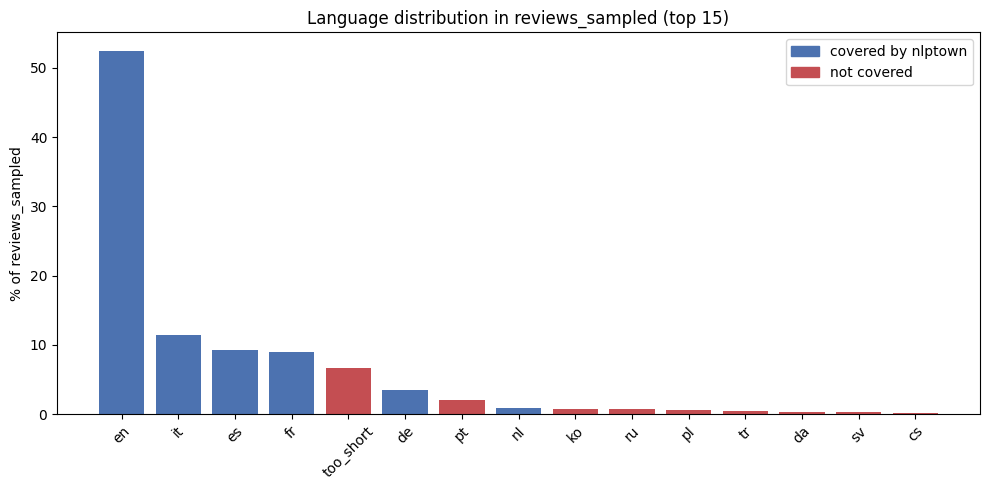

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
top15 = lang_coverage.head(15)
colors_lang = ['#4c72b0' if covered else '#c44e52' for covered in top15['covered_by_nlptown']]
ax.bar(top15.index, top15['pct'], color=colors_lang)
ax.set_ylabel('% of reviews_sampled')
ax.set_title('Language distribution in reviews_sampled (top 15)')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4c72b0', label='covered by nlptown'),
                    Patch(color='#c44e52', label='not covered')])
plt.tight_layout()
plt.show()

**Observations:**

86.6% coverage confirms `nlptown` is a solid choice without needing a second model. The single largest "not covered" bucket isn't a missing language at all: `too_short` (6.68%) reflects the same detection-reliability limit already documented throughout this project (texts under 5 words), not a gap in the sentiment model's training. Among genuine language gaps, Portuguese is the largest at just 1.99%, followed by Russian at 0.72% (4,556 reviews), both too small to justify adding a second model with an incompatible output scale just to cover them. All languages outside `nlptown`'s six are marked `unavailable`, consistent with every other language-limited method in this project.

### 4.2 Model Loading & Label Verification

Before trusting any star-weight mapping, the model's actual `id2label` ordering is checked directly on the loaded object.

In [14]:
import os
os.environ['HF_HUB_DISABLE_XET'] = '1'  # known, currently-broken Xet CAS backend — fall back to plain HTTP download

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
HF_CACHE_DIR = BASE_PATH / 'models' / 'huggingface_cache'  

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR).to(DEVICE)
model.eval()

print(model.config.id2label)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6177.18it/s]


{0: '1 star', 1: '2 stars', 2: '3 stars', 3: '4 stars', 4: '5 stars'}


### 4.3 Sentiment Inference

Per-review sentiment is computed via expected value over the model's softmax probabilities (Σ i × P(star_i)), which uses the model's full confidence distribution instead of collapsing it to a single hard class, giving a genuinely continuous score for listing-level mean/std aggregation. The same continuous score is also thresholded into a `negative`/`neutral`/`positive` category, so both the star-comparison narrative (vs. `review_scores_rating`'s ceiling effect) and the standard %negative framing come from one model, one pass, not two separate methods.

Inference runs in chunks of 20,000 reviews, saved to disk incrementally with a `review_index` column tying each score back to its exact row in `reviews_sampled`.

In [15]:
STAR_WEIGHTS = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0]).to(DEVICE) 
model_fp16 = model.half()

def predict_sentiment_batch_fast(texts, batch_size=128, max_length=256):
    n = len(texts)
    order = sorted(range(n), key=lambda i: len(texts[i]))
    sorted_texts = [texts[i] for i in order]

    scores_sorted = [None] * n
    for start in range(0, n, batch_size):
        batch = sorted_texts[start:start + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(DEVICE)
        with torch.inference_mode():
            logits = model_fp16(**inputs).logits
        probs = F.softmax(logits.float(), dim=-1)
        batch_scores = (probs * STAR_WEIGHTS).sum(dim=-1).cpu().tolist()
        for j, score in enumerate(batch_scores):
            scores_sorted[start + j] = score

    scores = [None] * n
    for sorted_idx, orig_idx in enumerate(order):
        scores[orig_idx] = scores_sorted[sorted_idx]
    return scores

def star_to_category(score, neg_max=2.5, pos_min=3.5):
    """Threshold a continuous star score into negative/neutral/positive."""
    if score <= neg_max:
        return 'negative'
    elif score >= pos_min:
        return 'positive'
    return 'neutral'

In [16]:
import os
import time

SENTIMENT_CHUNK_SIZE = 20_000
SENTIMENT_OUTPUT_DIR = BASE_PATH / 'data' / 'sentiment_chunks'
SENTIMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

n_chunks = (len(reviews_sampled) + SENTIMENT_CHUNK_SIZE - 1) // SENTIMENT_CHUNK_SIZE
print(f"{len(reviews_sampled):,} reviews -> {n_chunks} chunks of up to {SENTIMENT_CHUNK_SIZE:,} each")

for chunk_idx in range(n_chunks):
    chunk_path = SENTIMENT_OUTPUT_DIR / f'chunk_{chunk_idx:03d}.csv'
    if chunk_path.exists():
        continue 

    start_idx = chunk_idx * SENTIMENT_CHUNK_SIZE
    end_idx = min(start_idx + SENTIMENT_CHUNK_SIZE, len(reviews_sampled))
    chunk = reviews_sampled.iloc[start_idx:end_idx]

    chunk_start_time = time.time()
    scores = predict_sentiment_batch_fast(chunk['comments_clean'].tolist(), batch_size=128)
    chunk_elapsed = time.time() - chunk_start_time

    result = pd.DataFrame({
        'review_index': chunk.index, 
        'listing_id': chunk['listing_id'].values,
        'sentiment_star_score': scores,
    })
    result.to_csv(chunk_path, index=False)

    print(f"chunk {chunk_idx + 1}/{n_chunks} done in {chunk_elapsed/60:.1f} min "
          f"({(chunk_idx + 1) * SENTIMENT_CHUNK_SIZE / len(reviews_sampled) * 100:.1f}% overall)")

631,250 reviews -> 32 chunks of up to 20,000 each


In [17]:
SENTIMENT_OUTPUT_DIR = BASE_PATH / 'data' / 'sentiment_chunks'

chunk_files = sorted(SENTIMENT_OUTPUT_DIR.glob('chunk_*.csv'))
print(f"{len(chunk_files)} chunk files")

sentiment_results = pd.concat([pd.read_csv(f) for f in chunk_files], ignore_index=True)
print(f"total sentiment predictions: {len(sentiment_results):,}")
print(f"len of reviews_sampled: {len(reviews_sampled):,}")

assert len(sentiment_results) == len(reviews_sampled), "row count mismatch — investigate before merging"

32 chunk files
total sentiment predictions: 631,250
len of reviews_sampled: 631,250


In [18]:
# align sentiment_results to reviews_sampled via the saved review_index,
sentiment_results_sorted = sentiment_results.set_index('review_index').sort_index()
index_match = sentiment_results_sorted.index.equals(reviews_sampled.index.sort_values())
print(f"review_index fully covers reviews_sampled: {index_match}")

listing_id_check = (sentiment_results_sorted.loc[reviews_sampled.index, 'listing_id'].values == reviews_sampled['listing_id'].values).all()
print(f"listing_id alignment via review_index confirmed: {listing_id_check}")

review_index fully covers reviews_sampled: True
listing_id alignment via review_index confirmed: True


In [19]:
reviews_sampled['sentiment_star_score'] = sentiment_results_sorted.loc[reviews_sampled.index, 'sentiment_star_score'].values
reviews_sampled['sentiment_category'] = reviews_sampled['sentiment_star_score'].apply(star_to_category)

print(reviews_sampled[['listing_id', 'comments_clean', 'sentiment_star_score', 'sentiment_category']].head())
print(f"\nmissing sentiment scores: {reviews_sampled['sentiment_star_score'].isna().sum()}")

   listing_id                                     comments_clean  \
0    52751914  die wohnung von luca ist sehr zentral gelegen ...   
1     5333398  that was our second stay at thea's place and i...   
2     1325870  sabrina was a great host, really willing to he...   
3    17183851  the apartment is great. we loved the neighborh...   
4    14184214  what a perfect place for everything! central t...   

   sentiment_star_score sentiment_category  
0              4.541930           positive  
1              4.407574           positive  
2              4.615089           positive  
3              4.475680           positive  
4              4.969585           positive  

missing sentiment scores: 0


### 4.4 Listing-Level Aggregation

Four features are aggregated from the per-review scores in `reviews_sampled`: mean sentiment (overall tone), standard deviation (how much guests disagree — a listing with wildly mixed reviews is a different signal than one with uniformly moderate ones), percent negative (share of reviews below the negative threshold), and trend (whether sentiment is improving or declining over time). All four are computed only from each listing's valid (non-`unavailable`) reviews; listings with zero valid reviews get `NaN` throughout, consistent with the coverage gap just established.

Trend is computed as the slope of a simple linear regression of sentiment score against review order (sorted by date, oldest first) within each listing — a positive slope means sentiment has been improving over the listing's review history, negative means declining. This is left undefined (`NaN`) for listings with fewer than 3 valid, dated reviews, since a trend line through 1-2 points is not a meaningful signal.

In [20]:
reviews_sampled['sentiment_lang_covered'] = reviews_sampled['review_lang'].isin(NLPTOWN_LANGS)

reviews_sampled.loc[~reviews_sampled['sentiment_lang_covered'], 'sentiment_star_score'] = np.nan
reviews_sampled.loc[~reviews_sampled['sentiment_lang_covered'], 'sentiment_category'] = 'unavailable'

listing_review_counts = reviews_sampled.groupby('listing_id').size()
listing_sentiment_available = reviews_sampled.groupby('listing_id')['sentiment_star_score'].apply(lambda x: x.notna().sum())

n_listings_total = listing_review_counts.shape[0]
n_listings_zero_coverage = (listing_sentiment_available == 0).sum()
n_listings_full = (listing_sentiment_available == listing_review_counts).sum() 
n_listings_partial = n_listings_total - n_listings_zero_coverage - n_listings_full

print(f"total listings: {n_listings_total:,}")
print(f"listings with zero valid sentiment scores: {n_listings_zero_coverage:,} ({n_listings_zero_coverage/n_listings_total*100:.2f}%)")
print(f"listings with partial coverage: {n_listings_partial:,} ({n_listings_partial/n_listings_total*100:.1f}%)")
print(f"listings with full coverage (100% of their own sampled reviews): {n_listings_full:,} ({n_listings_full/n_listings_total*100:.1f}%)")

total listings: 32,250
listings with zero valid sentiment scores: 447 (1.39%)
listings with partial coverage: 24,735 (76.7%)
listings with full coverage (100% of their own sampled reviews): 7,068 (21.9%)


1.4% of listings end up with zero valid sentiment scores, nearly all of them listings with very few sampled reviews to begin with, where the small sample size made an all-unsupported-language draw plausible by chance. The remaining 98.6% retain at least one valid score, split between full coverage (21.9%, every sampled review valid) and partial coverage (76.7%, some but not all reviews valid), handled by aggregation the same way every other partially-available NLP feature in this project is, computed on whatever valid data exists. The 1.4% zero-coverage listings will carry `NaN` across every sentiment aggregate that follows, a small, acknowledged limitation of a single-language-family model applied to a genuinely multilingual corpus.

In [21]:
from scipy.stats import linregress

reviews_sampled['date'] = pd.to_datetime(reviews_sampled['date'])

TREND_SIGNIFICANCE_ALPHA = 0.05

def compute_sentiment_trend(group):
    """Slope + significance of sentiment score over review order (oldest to newest).
    Requires at least 3 valid, dated reviews to be meaningful. Returns both slope
    and p_value in one regression call, rather than computing it twice."""
    valid = group.dropna(subset=['sentiment_star_score', 'date']).sort_values('date')
    if len(valid) < 3:
        return pd.Series({'sentiment_trend': np.nan, 'sentiment_trend_pvalue': np.nan})
    x = np.arange(len(valid))
    slope, _, _, p_value, _ = linregress(x, valid['sentiment_star_score'].values)
    return pd.Series({'sentiment_trend': slope, 'sentiment_trend_pvalue': p_value})

def classify_trend(row, alpha=TREND_SIGNIFICANCE_ALPHA):
    """Categorical trend: only calls a direction if the slope is statistically
    distinguishable from zero — a small, noisy sample defaults to 'stable'
    rather than trusting an arbitrary raw sign."""
    if pd.isna(row['sentiment_trend']) or pd.isna(row['sentiment_trend_pvalue']):
        return 'unavailable'
    if row['sentiment_trend_pvalue'] >= alpha:
        return 'stable'
    return 'improving' if row['sentiment_trend'] > 0 else 'declining'

sentiment_agg = reviews_sampled.groupby('listing_id').agg(
    sentiment_mean=('sentiment_star_score', 'mean'),
    sentiment_std=('sentiment_star_score', 'std'),
    n_valid_sentiment=('sentiment_star_score', 'count'),
)

sentiment_agg['sentiment_pct_negative'] = reviews_sampled.groupby('listing_id')['sentiment_category'].apply(
    lambda x: (x == 'negative').sum() / (x != 'unavailable').sum() if (x != 'unavailable').sum() > 0 else np.nan
)
sentiment_agg['sentiment_pct_positive'] = reviews_sampled.groupby('listing_id')['sentiment_category'].apply(
    lambda x: (x == 'positive').sum() / (x != 'unavailable').sum() if (x != 'unavailable').sum() > 0 else np.nan
)
sentiment_agg['sentiment_pct_neutral'] = reviews_sampled.groupby('listing_id')['sentiment_category'].apply(
    lambda x: (x == 'neutral').sum() / (x != 'unavailable').sum() if (x != 'unavailable').sum() > 0 else np.nan
)

trend_results = reviews_sampled.groupby('listing_id').apply(compute_sentiment_trend)
sentiment_agg = sentiment_agg.join(trend_results)
sentiment_agg['sentiment_trend_category'] = sentiment_agg.apply(classify_trend, axis=1)

print(f"listings with sentiment_mean computed: {sentiment_agg['sentiment_mean'].notna().sum():,} / {len(sentiment_agg):,}")
print(f"listings with sentiment_trend computed: {sentiment_agg['sentiment_trend'].notna().sum():,} / {len(sentiment_agg):,}")
print(f"\nsentiment_trend_category breakdown:")
print(sentiment_agg['sentiment_trend_category'].value_counts())
display(sentiment_agg.describe())

listings with sentiment_mean computed: 31,803 / 32,250
listings with sentiment_trend computed: 27,695 / 32,250

sentiment_trend_category breakdown:
sentiment_trend_category
stable         26136
unavailable     4555
declining       1079
improving        480
Name: count, dtype: int64


,sentiment_mean,sentiment_std,n_valid_sentiment,sentiment_pct_negative,sentiment_pct_positive,sentiment_pct_neutral,sentiment_trend,sentiment_trend_pvalue
count,31803.000000,29390.000000,32250.000000,31803.000000,31803.000000,31803.000000,27695.000000,27695.000000
mean,4.462087,0.440893,16.938605,0.021343,0.941044,0.037613,-0.010173,0.477495
std,0.319539,0.269484,10.392186,0.081784,0.124900,0.092185,0.119735,0.291437
min,1.061326,0.000453,0.000000,0.000000,0.000000,0.000000,-1.812240,0.000021
25%,4.379596,0.254388,6.000000,0.000000,0.925926,0.000000,-0.015799,0.221555
50%,4.528271,0.376254,21.000000,0.000000,1.000000,0.000000,-0.002900,0.460622
75%,4.636018,0.572300,26.000000,0.000000,1.000000,0.041667,0.007707,0.729199
max,4.981588,2.663572,30.000000,1.000000,1.000000,1.000000,1.631617,0.999995


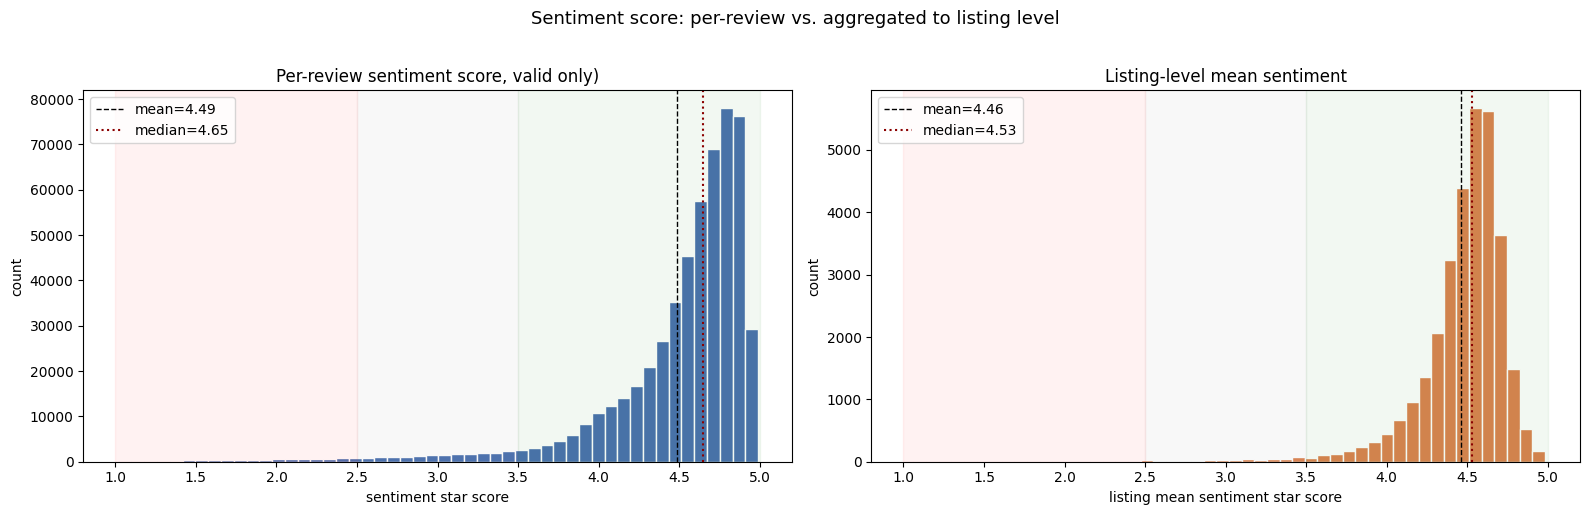

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: per-review, raw
valid_scores = reviews_sampled['sentiment_star_score'].dropna()
axes[0].hist(valid_scores, bins=50, color='#4c72b0', edgecolor='white')
axes[0].axvline(valid_scores.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={valid_scores.mean():.2f}')
axes[0].axvline(valid_scores.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={valid_scores.median():.2f}')
axes[0].axvspan(1, 2.5, color='red', alpha=0.05)
axes[0].axvspan(2.5, 3.5, color='grey', alpha=0.05)
axes[0].axvspan(3.5, 5, color='green', alpha=0.05)
axes[0].set_xlabel('sentiment star score')
axes[0].set_ylabel('count')
axes[0].set_title(f'Per-review sentiment score, valid only)')
axes[0].legend()

# right: listing-level mean, same color-coded background bands
listing_means = sentiment_agg['sentiment_mean'].dropna()
axes[1].hist(listing_means, bins=50, color='#dd8452', edgecolor='white')
axes[1].axvline(listing_means.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={listing_means.mean():.2f}')
axes[1].axvline(listing_means.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={listing_means.median():.2f}')
axes[1].axvspan(1, 2.5, color='red', alpha=0.05)
axes[1].axvspan(2.5, 3.5, color='grey', alpha=0.05)
axes[1].axvspan(3.5, 5, color='green', alpha=0.05)
axes[1].set_xlabel('listing mean sentiment star score')
axes[1].set_ylabel('count')
axes[1].set_title(f'Listing-level mean sentiment')
axes[1].legend()

plt.suptitle('Sentiment score: per-review vs. aggregated to listing level', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The per-review → listing-level comparison shows the smoothing effect expected from averaging up to 30 reviews per listing: the per-review distribution has real weight in the red zone and a long left tail, while the listing-level mean distribution is visibly narrower and almost entirely clear of that zone. This is the same aggregation-smoothing pattern already documented for `review_mtld`/`review_readability` earlier, as individual bad experiences get diluted into a listing's overall profile, which is expected at this level of aggregation.

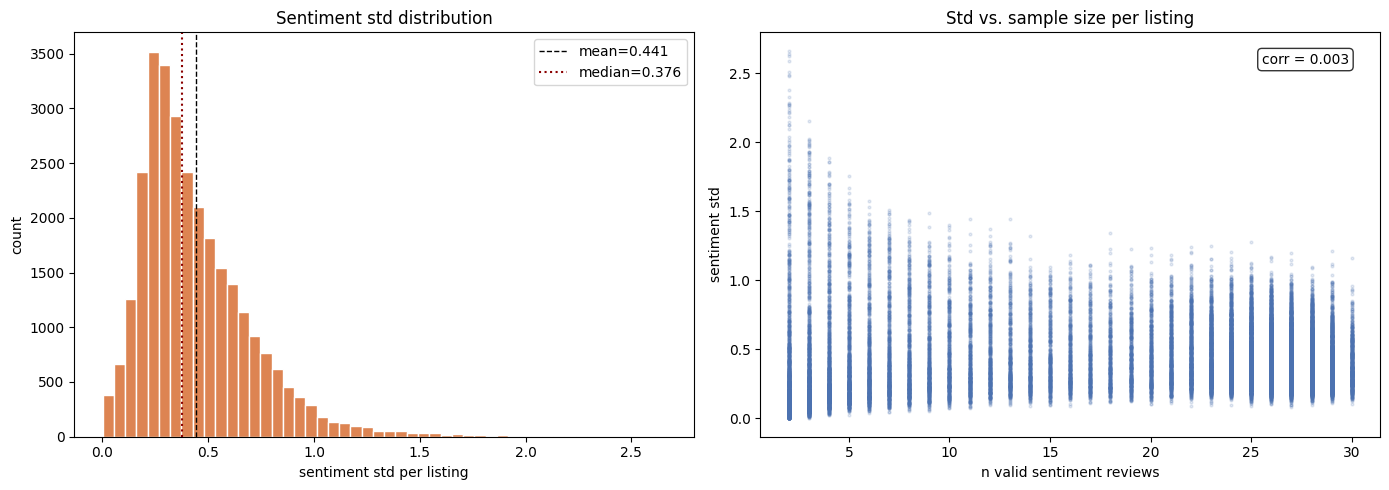

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of std itself
std_data = sentiment_agg['sentiment_std'].dropna()
axes[0].hist(std_data, bins=50, color='#dd8452', edgecolor='white')
axes[0].axvline(std_data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={std_data.mean():.3f}')
axes[0].axvline(std_data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={std_data.median():.3f}')
axes[0].set_xlabel('sentiment std per listing')
axes[0].set_ylabel('count')
axes[0].set_title(f'Sentiment std distribution')
axes[0].legend()

# std vs. n_valid_sentiment 
plot_data = sentiment_agg.dropna(subset=['sentiment_std', 'n_valid_sentiment'])
axes[1].scatter(plot_data['n_valid_sentiment'], plot_data['sentiment_std'], s=4, alpha=0.15, color='#4c72b0')
axes[1].set_xlabel('n valid sentiment reviews')
axes[1].set_ylabel('sentiment std')
axes[1].set_title('Std vs. sample size per listing')

corr = plot_data['n_valid_sentiment'].corr(plot_data['sentiment_std'])
axes[1].text(0.95, 0.95, f'corr = {corr:.3f}', transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

`sentiment_std` is right-skewed with a near-zero linear correlation to sample size, but the scatter itself tells a more precise story: it's a clear wedge/funnel shape, with std ranging from 0 to 2.6+ at low n (2-5 reviews) and narrowing to roughly 0-1.2 by n=30. Pearson correlation misses this because it's a shrinking-*variance*-of-the-estimate effect, not a linear shift in std's average level. A listing with 3 reviews can land anywhere in that wide range by chance, while a listing with 30 reviews can't.

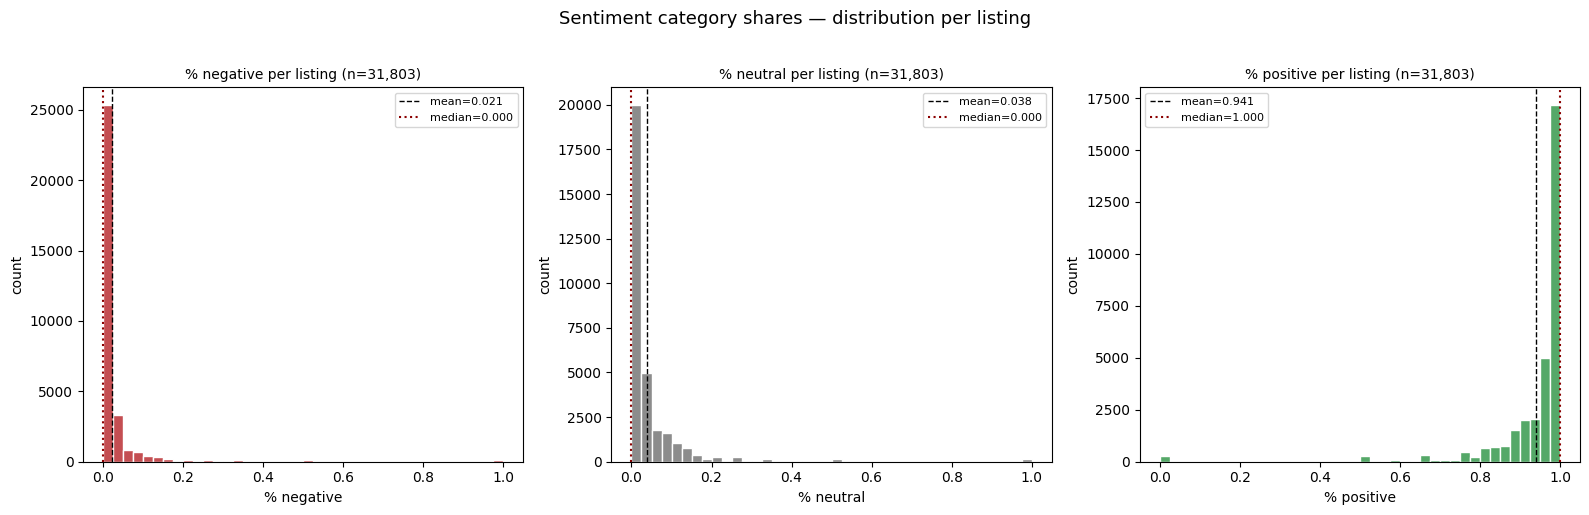

,mean,median,pct_zero,pct_one
sentiment_pct_negative,0.021,0.0,78.536,0.394
sentiment_pct_neutral,0.038,0.0,61.950,0.434
sentiment_pct_positive,0.941,1.0,0.874,53.203


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pct_cols = [
    ('sentiment_pct_negative', '% negative', '#c44e52'),
    ('sentiment_pct_neutral', '% neutral', '#8c8c8c'),
    ('sentiment_pct_positive', '% positive', '#55a868'),
]

for ax, (col, title, color) in zip(axes, pct_cols):
    data = sentiment_agg[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={data.mean():.3f}')
    ax.axvline(data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={data.median():.3f}')
    ax.set_xlabel(title)
    ax.set_ylabel('count')
    ax.set_title(f'{title} per listing (n={len(data):,})', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Sentiment category shares — distribution per listing', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

pct_summary = pd.DataFrame({
    col: {
        'mean': sentiment_agg[col].mean(),
        'median': sentiment_agg[col].median(),
        'pct_zero': (sentiment_agg[col] == 0).mean() * 100,
        'pct_one': (sentiment_agg[col] == 1).mean() * 100,
    }
    for col, _, _ in pct_cols
}).T

display(pct_summary.round(3))

The three category shares confirm the corpus is overwhelmingly positive: `sentiment_pct_positive` has a median of 1.0 and 53.2% of listings sit exactly there, while `pct_negative` and `pct_neutral` are heavily zero-inflated (78.5% and 62.0% zero respectively). This isn't a flaw in the method, as guest reviews are a well-documented positively-skewed genre, but it does mean these three columns are strong candidates for the binary flags or tiered binning already, rather than being fed into clustering as raw continuous shares.

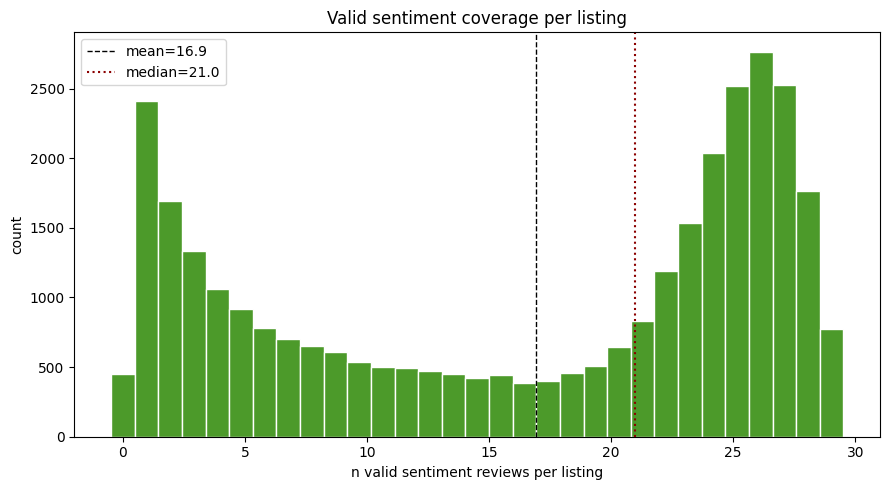

listings with 0 valid reviews: 447 (1.4%)


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

n_valid_data = sentiment_agg['n_valid_sentiment']

ax.hist(n_valid_data, bins=31, color='#4c9a2a', edgecolor='white', align='left')
ax.axvline(n_valid_data.mean(), color='black', linestyle='--', linewidth=1, label=f'mean={n_valid_data.mean():.1f}')
ax.axvline(n_valid_data.median(), color='darkred', linestyle=':', linewidth=1.5, label=f'median={n_valid_data.median():.1f}')
ax.set_xlabel('n valid sentiment reviews per listing')
ax.set_ylabel('count')
ax.set_title(f'Valid sentiment coverage per listing')
ax.legend()
plt.tight_layout()
plt.show()

print(f"listings with 0 valid reviews: {(n_valid_data == 0).sum():,} ({(n_valid_data == 0).mean()*100:.1f}%)")

`n_valid_sentiment` has a mildly bimodal shape. This reflects two distinct listing populations: those where language coverage or review volume was thin to begin with, and those where nearly the full 30-review sample survived the language filter intact.

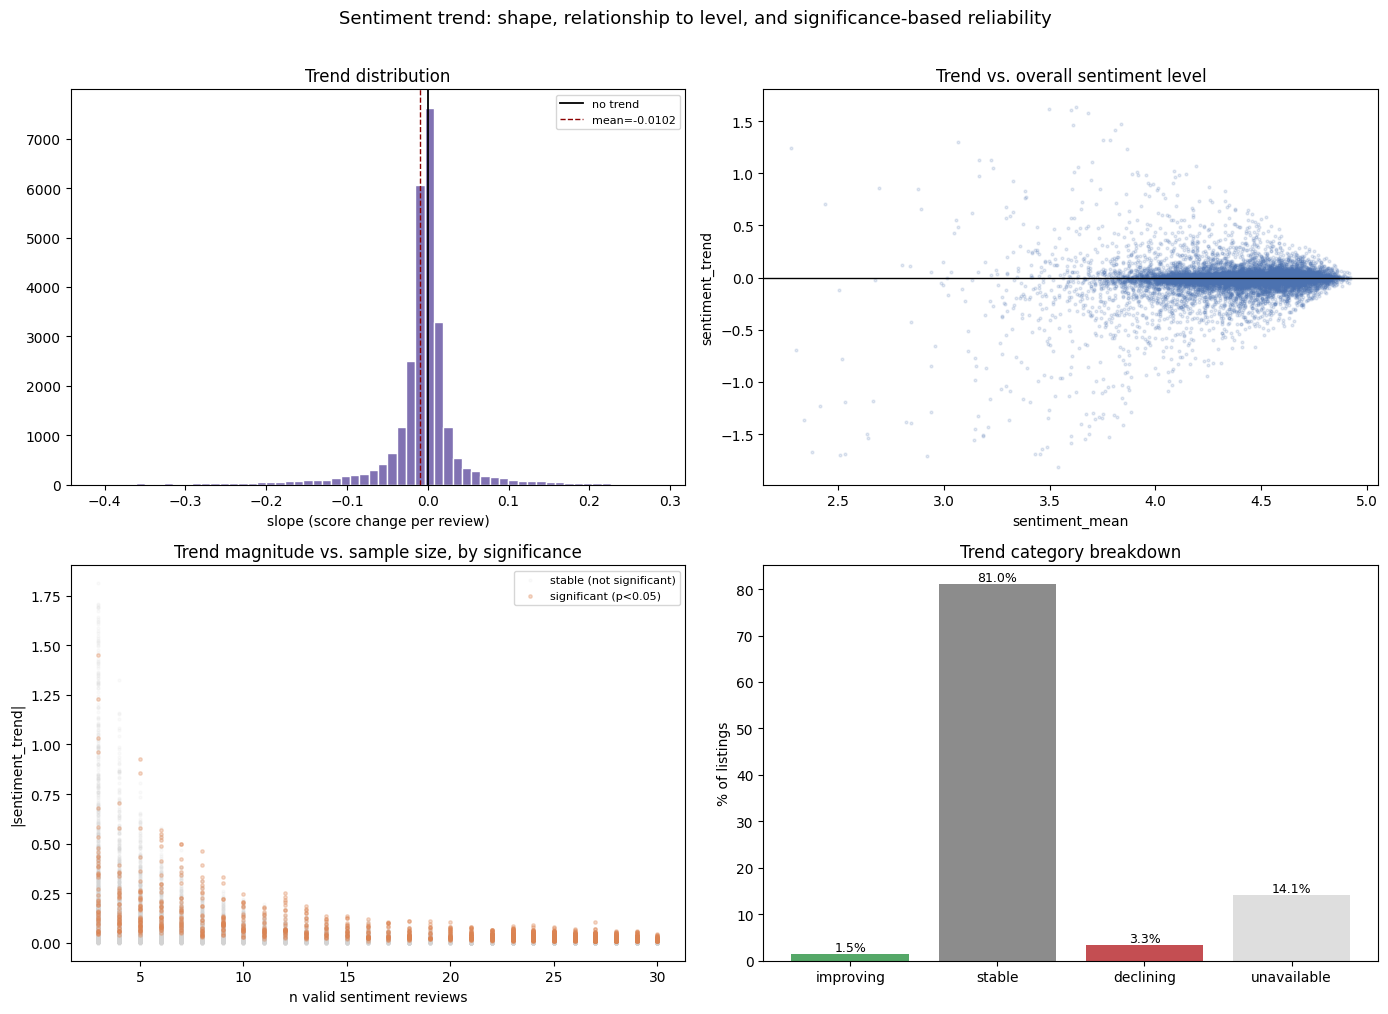

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

trend_data = sentiment_agg['sentiment_trend'].dropna()

# 1. distribution
lower, upper = trend_data.quantile(0.01), trend_data.quantile(0.99)
clipped = trend_data[(trend_data >= lower) & (trend_data <= upper)]
axes[0, 0].hist(clipped, bins=60, color='#8172b3', edgecolor='white')
axes[0, 0].axvline(0, color='black', linewidth=1.3, label='no trend')
axes[0, 0].axvline(trend_data.mean(), color='darkred', linestyle='--', linewidth=1, label=f'mean={trend_data.mean():.4f}')
axes[0, 0].set_xlabel('slope (score change per review)')
axes[0, 0].set_title('Trend distribution')
axes[0, 0].legend(fontsize=8)

# 2. trend vs. overall sentiment level
plot_data = sentiment_agg.dropna(subset=['sentiment_trend', 'sentiment_mean'])
axes[0, 1].scatter(plot_data['sentiment_mean'], plot_data['sentiment_trend'], s=4, alpha=0.15, color='#4c72b0')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_xlabel('sentiment_mean')
axes[0, 1].set_ylabel('sentiment_trend')
axes[0, 1].set_title('Trend vs. overall sentiment level')

# 3. trend magnitude vs. sample size, colored by significance
plot_data2 = sentiment_agg.dropna(subset=['sentiment_trend', 'n_valid_sentiment', 'sentiment_trend_category'])
sig_mask = plot_data2['sentiment_trend_category'].isin(['improving', 'declining'])
axes[1, 0].scatter(plot_data2.loc[~sig_mask, 'n_valid_sentiment'], plot_data2.loc[~sig_mask, 'sentiment_trend'].abs(),
                    s=4, alpha=0.1, color='lightgrey', label='stable (not significant)')
axes[1, 0].scatter(plot_data2.loc[sig_mask, 'n_valid_sentiment'], plot_data2.loc[sig_mask, 'sentiment_trend'].abs(),
                    s=6, alpha=0.3, color='#dd8452', label='significant (p<0.05)')
axes[1, 0].set_xlabel('n valid sentiment reviews')
axes[1, 0].set_ylabel('|sentiment_trend|')
axes[1, 0].set_title('Trend magnitude vs. sample size, by significance')
axes[1, 0].legend(fontsize=8)

# 4. category breakdown
cat_counts = sentiment_agg['sentiment_trend_category'].value_counts().reindex(
    ['improving', 'stable', 'declining', 'unavailable']
).fillna(0)
cat_pct = cat_counts / cat_counts.sum() * 100
colors_cat = ['#55a868', '#8c8c8c', '#c44e52', '#dedede']
axes[1, 1].bar(cat_pct.index, cat_pct.values, color=colors_cat)
axes[1, 1].set_ylabel('% of listings')
axes[1, 1].set_title('Trend category breakdown')
for i, v in enumerate(cat_pct.values):
    axes[1, 1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Sentiment trend: shape, relationship to level, and significance-based reliability', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

`sentiment_trend` sits close to zero on average, consistent with most listings having no strong directional history. Raw slope magnitude follows a funnel pattern against sample size, as the |slope| reaches 1.75+ at n=3 and compresses to under ~0.25 by n=30, so a regression through very few points can produce a large, misleading slope purely from noise. To separate a genuine trend from this small-sample artifact, each listing's slope is paired with its regression p-value, and only slopes distinguishable from zero (p<0.05) are labeled `improving`/`declining` and everything else defaults to `stable` rather than trusting an arbitrary sign. The resulting breakdown is heavily `stable` (81.0%), with `improving` (1.5%) and `declining` (3.3%) as a small, statistically defensible minority, and `unavailable` (14.1%) for listings with fewer than 3 valid, dated reviews.

### 4.5 Validation Against Numeric Review Scores

This subsection tests whether text-derived sentiment reveal variation that `review_scores_rating`'s ceiling effect hides?

In [27]:
# merge sentiment_agg and listings_nlp
existing_sentiment_cols = [c for c in sentiment_agg.columns if c in listings_nlp.columns]
if existing_sentiment_cols:
    listings_nlp = listings_nlp.drop(columns=existing_sentiment_cols)

listings_nlp = listings_nlp.merge(sentiment_agg, left_on='id', right_index=True, how='left')

n_total = len(listings_nlp)
n_with_sentiment = listings_nlp['sentiment_mean'].notna().sum()
n_without = n_total - n_with_sentiment

print(f"total listings: {n_total:,}")
print(f"with sentiment_mean: {n_with_sentiment:,} ({n_with_sentiment/n_total*100:.1f}%)")
print(f"without (NaN): {n_without:,} ({n_without/n_total*100:.1f}%)")

total listings: 35,818
with sentiment_mean: 30,290 (84.6%)
without (NaN): 5,528 (15.4%)


In [28]:
# ceiling check
ceiling_check = listings_nlp['review_scores_rating_raw'].quantile([0.75, 0.90, 0.95, 0.97, 0.99, 1.0])
display(ceiling_check.to_frame('review_scores_rating_raw'))

pct_at_max = (listings_nlp['review_scores_rating_raw'] == listings_nlp['review_scores_rating_raw'].max()).mean() * 100
print(f"\nlistings at the exact maximum: {pct_at_max:.1f}%")

,review_scores_rating_raw
0.75,4.97
0.90,5.00
0.95,5.00
0.97,5.00
0.99,5.00
1.00,5.00



listings at the exact maximum: 19.7%


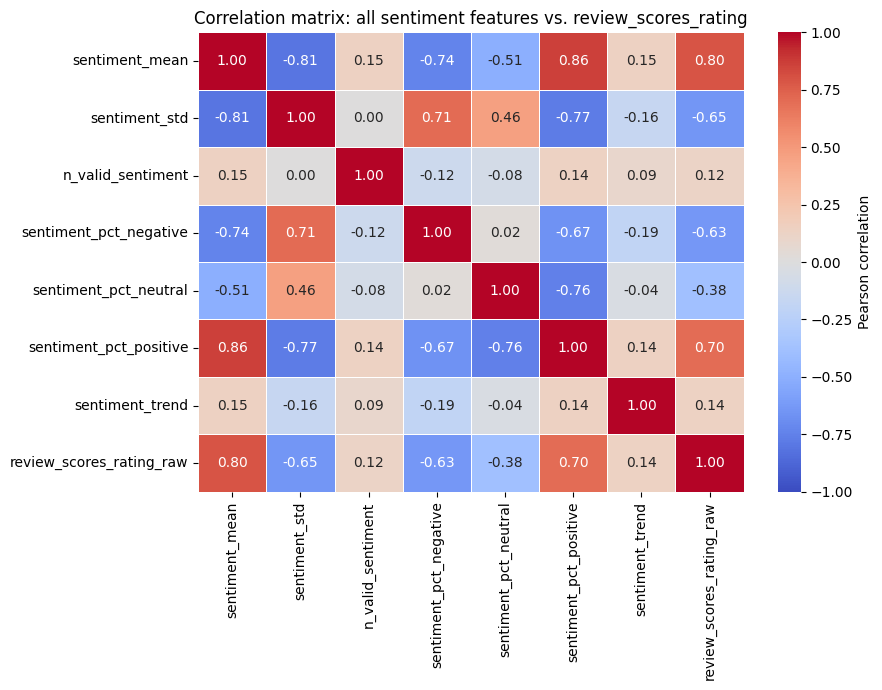

In [29]:
# correlation check
sentiment_vars = [
    'sentiment_mean', 'sentiment_std', 'n_valid_sentiment',
    'sentiment_pct_negative', 'sentiment_pct_neutral', 'sentiment_pct_positive',
    'sentiment_trend', 'review_scores_rating_raw'
]

corr_matrix = listings_nlp[sentiment_vars].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Correlation matrix: all sentiment features vs. review_scores_rating')
plt.tight_layout()
plt.show()

The heatmap confirms `review_scores_rating` correlates most strongly with `sentiment_mean` and `sentiment_pct_positive`, moderately with `sentiment_pct_negative` and `sentiment_std`, and only weakly with `sentiment_trend` and `n_valid_sentiment`, as they are structurally unrelated to a listing's quality level.

The internal structure among the sentiment variables themselves is informative in its own right. `sentiment_std` correlates negatively with `sentiment_mean` and positively with `sentiment_pct_negative`, which is mechanically expected, since a listing pinned near the ceiling has little room left to vary, while a listing with mixed reviews both scores lower on average and disagrees more. `sentiment_pct_neutral` stands out as behaving differently from `pct_negative`: it correlates only weakly with `review_scores_rating` and barely at all with `sentiment_mean` or `pct_negative`, consistent with "neutral" capturing lukewarm-but-not-complaining reviews rather than functioning as a softer version of negative, a genuinely distinct signal rather than a redundant one.

`sentiment_trend`'s near-total independence from every other sentiment variable reinforces the earlier finding: with 81% of listings landing in the conservative `stable` category, trend captures a narrow, largely orthogonal slice of information that the level-based metrics don't touch at all.

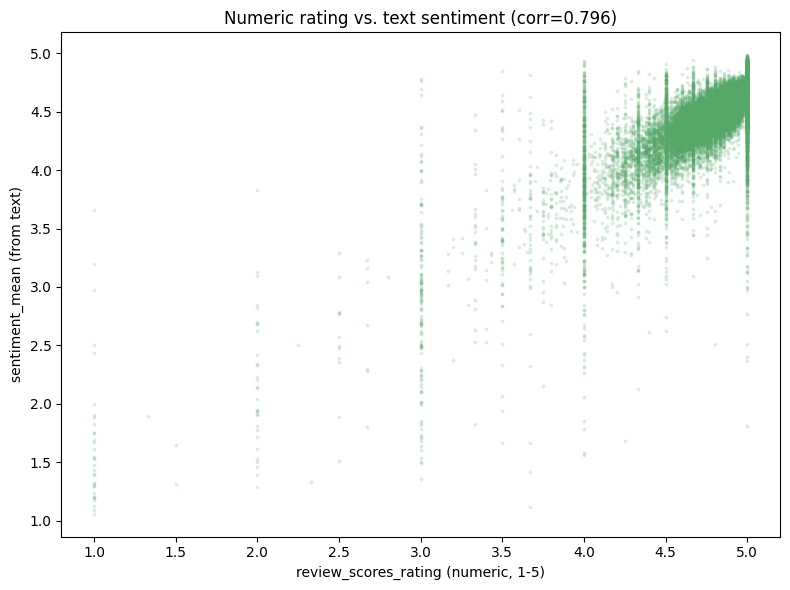

In [30]:
# scatter - reviews_score_rating vs sentiment_mean
plot_data = listings_nlp.dropna(subset=['review_scores_rating_raw', 'sentiment_mean'])
corr = plot_data['review_scores_rating_raw'].corr(plot_data['sentiment_mean'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_data['review_scores_rating_raw'], plot_data['sentiment_mean'], s=3, alpha=0.15, color='#55a868')
ax.set_xlabel('review_scores_rating (numeric, 1-5)')
ax.set_ylabel('sentiment_mean (from text)')
ax.set_title(f'Numeric rating vs. text sentiment (corr={corr:.3f})')
plt.tight_layout()
plt.show()

The direct correlation between `review_scores_rating` and `sentiment_mean` is stronger than initially expected. 0.796, not the weak-to-moderate range originally anticipated. It does mean the overall correlation coefficient alone can't be the primary evidence for the thesis: it's driven heavily by the extreme low end of the rating scale (1-3), where both numeric rating and text sentiment agree strongly that something went badly wrong, which is expected and reassuring. The real test is the vertical spread visible at each rating value, especially at rating=5.0, where `sentiment_mean` ranges all the way from below 2.0 up to 5.0 despite the numeric score showing zero variance.

12,605 listings with review_scores_rating >= 4.9 (numeric ceiling)
sentiment_mean within this group — std=0.164, range=[1.81, 4.98], IQR=[4.56, 4.71]


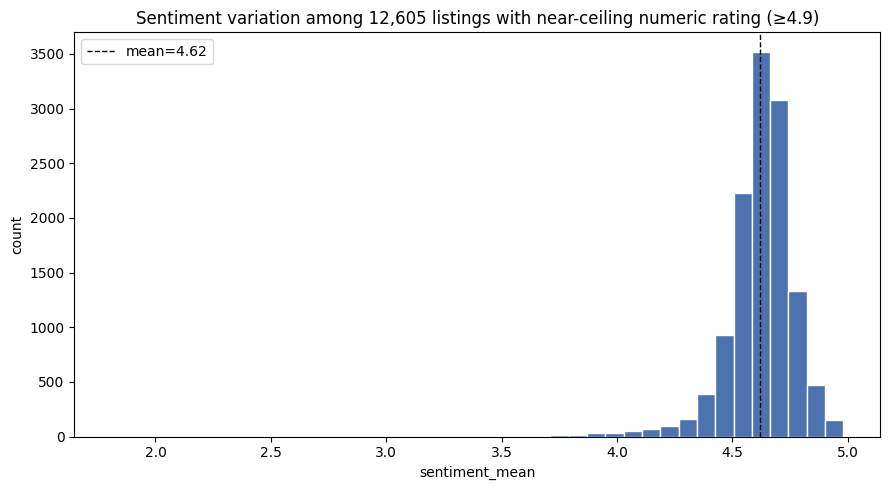

In [31]:
# sentiment variation whihin listings with review_scores_rating > 75th percentile
CEILING_THRESHOLD = 4.9
near_ceiling = listings_nlp[listings_nlp['review_scores_rating_raw'] >= CEILING_THRESHOLD].dropna(subset=['sentiment_mean'])

print(f"{len(near_ceiling):,} listings with review_scores_rating >= {CEILING_THRESHOLD} (numeric ceiling)")
print(f"sentiment_mean within this group — std={near_ceiling['sentiment_mean'].std():.3f}, "
      f"range=[{near_ceiling['sentiment_mean'].min():.2f}, {near_ceiling['sentiment_mean'].max():.2f}], "
      f"IQR=[{near_ceiling['sentiment_mean'].quantile(0.25):.2f}, {near_ceiling['sentiment_mean'].quantile(0.75):.2f}]")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(near_ceiling['sentiment_mean'], bins=40, color='#4c72b0', edgecolor='white')
ax.axvline(near_ceiling['sentiment_mean'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"mean={near_ceiling['sentiment_mean'].mean():.2f}")
ax.set_xlabel('sentiment_mean')
ax.set_ylabel('count')
ax.set_title(f'Sentiment variation among {len(near_ceiling):,} listings with near-ceiling numeric rating (≥{CEILING_THRESHOLD})')
ax.legend()
plt.tight_layout()
plt.show()

Restricting to the 12,605 listings already pinned at the numeric ceiling (rating ≥ 4.9), where the numeric score has essentially nothing left to say,`sentiment_mean` shows real, non-trivial spread: mean 4.62, with a visible left tail reaching down toward 3.5-4.0 and a handful of listings even lower. This is the direct, concrete confirmation that text sentiment recovers meaningful variation among listings the numeric score treats as identical. The spread is modest in absolute terms, as most mass still sits in a fairly narrow 4.3-5.0 band, but modest, real variation where the alternative is *zero* variation is exactly the kind of signal a clustering algorithm can use that `review_scores_rating` cannot provide.

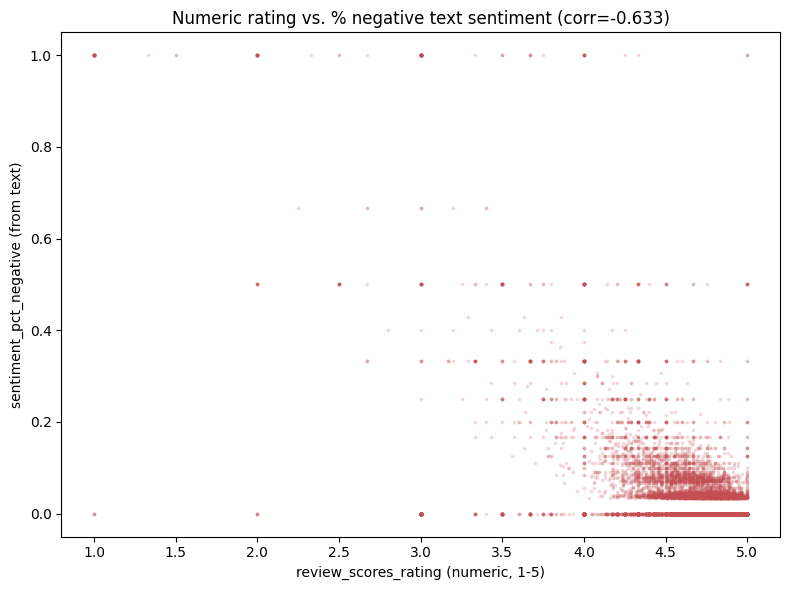

In [32]:
# connection between % negative and review_scores_rating
plot_data2 = listings_nlp.dropna(subset=['review_scores_rating_raw', 'sentiment_pct_negative'])
corr_neg = plot_data2['review_scores_rating_raw'].corr(plot_data2['sentiment_pct_negative'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_data2['review_scores_rating_raw'], plot_data2['sentiment_pct_negative'], s=3, alpha=0.15, color='#c44e52')
ax.set_xlabel('review_scores_rating (numeric, 1-5)')
ax.set_ylabel('sentiment_pct_negative (from text)')
ax.set_title(f'Numeric rating vs. % negative text sentiment (corr={corr_neg:.3f})')
plt.tight_layout()
plt.show()

The cross-check against `sentiment_pct_negative` confirms the expected direction, as higher numeric ratings correspond to a lower share of text-negative reviews, with a similar moderate-strong magnitude to the mean's correlation. The scatter shows the same reassuring pattern as `sentiment_mean`: broad agreement at the extremes (near-zero negative share for most high-rated listings, higher share at low ratings), but real scatter in between, including listings with a meaningfully elevated negative share despite a decent numeric rating, plausibly capturing dissatisfaction that gets rated tolerantly but described critically in text, a distinction the numeric score alone cannot make.

In [43]:
# merge each individual review with its listing's raw numeric rating
review_level_check = reviews_sampled.merge(
    listings_nlp[['id', 'review_scores_rating_raw']],
    left_on='listing_id', right_on='id', how='left'
)

HIGH_RATING_THRESHOLD = 4.8
eligible_mask = review_level_check['review_scores_rating_raw'] >= HIGH_RATING_THRESHOLD
disagreement_mask = eligible_mask & (review_level_check['sentiment_category'] == 'negative')

disagreement_reviews = review_level_check.loc[disagreement_mask]
print(f"{len(disagreement_reviews):,} reviews from high-rated listings (rating >= {HIGH_RATING_THRESHOLD}) "
      f"classified as negative sentiment")
print(f"({len(disagreement_reviews) / eligible_mask.sum() * 100:.2f}% of all reviews from high-rated listings)")

1,594 reviews from high-rated listings (rating >= 4.8) classified as negative sentiment
(0.43% of all reviews from high-rated listings)


In [45]:
pd.set_option('display.max_colwidth', 300)
sample_size = min(15, len(disagreement_reviews))
display(disagreement_reviews[
    ['listing_id', 'review_scores_rating_raw', 'sentiment_star_score', 'comments_clean']
].sample(sample_size, random_state=42))

,listing_id,review_scores_rating_raw,sentiment_star_score,comments_clean
349652,1167456420647971669,4.82,2.293919,stayed at this condo while in rome for a few days. travelled with our 2 children and the condo was specious for our size group. very basic and simple. good: • nice location with great restaurants near by. very close to vatican city. bad: •asked the host repeatedly before checking in to provide c...
428683,726566738053863467,4.96,1.679337,everything was beautiful except that airbnb forces me to write evaluations. if somebody offered me an evaluation free service i would switch imediately. what a nuisance!
493088,607674258805074435,4.82,2.019495,the location is the only good thing about this home; there are several steps up on to the living space from a extremely cramped elevator; if u are traveling with a few suitcases (which most tourists do) this is not the place for you. the key to the apartment is hard to operate. old lock and key ...
133608,42374839,4.86,2.188336,"la verdad que ha sido una experiencia un poco agridulce dado que ha tenido buenos aspectos y otros no tan buenos, en primer lugar el dia antes de llegar le escribi y no contesto hasta que no la volvi a escribir, una vez alli fue muy agradable con nosotras, incluso nos indico el camino para tomar..."
584774,1138908840636155532,4.90,2.189243,"emmanuelle was a great host. he greeted us to the apartment, helped us with the tricky street parking, gave us lots of local recommendations and was very responsive to my texts. the apartment looked very newly renovated, very clean with a fully stocked kitchen. the view was amazing, you could se..."
33246,29025044,4.99,2.464023,"the saddest part about our stay at this place was that it was only for one night! the apartment is located in a great neighbourhood with nearby shops, grocery stores, and restaurants. the rooms were tidy, clean, and comfortable. the beautiful terrace was the perfect spot to relax with a morning ..."
465723,52720621,4.84,2.207060,"la zona e’ molto distante dai mezzi di trasporto pubblico, arrivare in centro e’ un’odissea. non é chiara l’attinenza del modern apartament near trastevere. per raggiungere la linea 8 e’ necessario un quarto d’ora. parcheggiare la macchina? impossibile 🫣"
214602,633345945326273909,4.86,2.201269,"warning: there is no living room in this flat. if you don't need a living room during your stay, then this flat will suit you. we were very disappointed by the absence of a living room, contrary to what the ad says. if you don't need one, then the rooms are good, the furniture are nice and the c..."
415830,923061865610574271,4.83,1.946984,poco disponibile durante le fasi di check in.
260721,22336917,4.88,1.580378,"the host was terribly unresponsive duringg check in. his instructions were clear on the listing but he was nowhere to be found. if it wasn't for the maid, i have no clue how we would have gotten in. and after 14 hours of flights, that's the last thing we needed. maybe find another place to stay."


A direct read of 15 disagreement reviews (numeric rating ≥4.8, `sentiment_category = negative`) confirmed the bulk of the signal is genuine (hosts not responding, listing-description mismatches, broken amenities), but also surfaced a real limitation: 4-5 of the 15 were model misreads rather than hidden complaints (hyperbolic praise, a complaint about Airbnb's review process rather than the stay, a pickpocketing incident the reviewer explicitly disclaimed as unrelated to the host).

Since the full disagreement pool is only ~1,500 reviews, a much larger, systematic sample is realistic without a full manual read-through: 150 reviews are classified via the GPT-3.5-turbo infrastructure. A single structured, batched prompt asking the model to label each review as a genuine complaint or a likely sentiment-model misread (sarcasm, hyperbole, disclaimed blame, off-topic negativity), returning parseable JSON. This narrows the confidence interval enough to state an actual, citable error-rate estimate for `sentiment_pct_negative`'s disagreement signal.

In [46]:
from dotenv import load_dotenv
from openai import OpenAI, OpenAIError, RateLimitError, AuthenticationError, APIError
import json

load_dotenv('../config/.env')
api_key = os.environ.get('OPENAI_API_KEY')
if api_key is None:
    raise ValueError("OPENAI_API_KEY not found — check config/.env in the project root")

client = OpenAI(api_key=api_key)
api_exceptions = {
    RateLimitError: "Quota exceeded.",
    AuthenticationError: "Invalid API key.",
    APIError: "Problem with OpenAI server.",
    OpenAIError: "OpenAI returned an error.",
}

def strip_json_fences(text):
    text = text.strip()
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text.strip()

In [49]:
def build_classification_prompt(reviews_batch):
    header = (
        "For each numbered guest review below, the review comes from a listing with a very high "
        "star rating (4.8+), but a separate sentiment model flagged the review's TEXT as negative. "
        "Classify each review as either:\n"
        "- \"genuine\": the text describes a real, specific complaint or problem with the stay "
        "(unresponsive host, broken amenity, listing mismatch, noise, etc.)\n"
        "- \"misread\": the text is not actually a complaint about the stay — e.g. sarcasm, "
        "hyperbolic praise, a complaint unrelated to the listing itself (like Airbnb's review process), "
        "or a negative event the reviewer explicitly says was NOT the host's fault\n"
        "Return ONLY valid JSON, no commentary, mapping each review number to its label:\n"
        '{"1": "genuine", "2": "misread", ...}\n\n'
    )
    body = "\n".join(f"{i+1}. {text}" for i, text in enumerate(reviews_batch))
    return header + body

def classify_disagreement_batch(client, reviews_batch, model="gpt-3.5-turbo"):
    prompt = build_classification_prompt(reviews_batch)
    raw_text = None
    try:
        response = client.responses.create(model=model, input=prompt, temperature=0)
        raw_text = strip_json_fences(response.output_text)
        return json.loads(raw_text)
    except tuple(api_exceptions.keys()) as e:
        print(api_exceptions[type(e)])
        return None
    except json.JSONDecodeError as e:
        print(f"Response wasn't valid JSON: {e}")
        if raw_text:
            print(raw_text)
        return None

In [50]:
DISAGREEMENT_SAMPLE_SIZE = 150
BATCH_SIZE_LLM = 50  # reviews per API call, keeps prompts within context limits

classification_sample = disagreement_reviews.sample(
    min(DISAGREEMENT_SAMPLE_SIZE, len(disagreement_reviews)), random_state=42
).reset_index(drop=True)

all_labels = {}
texts = classification_sample['comments_clean'].tolist()

for start in range(0, len(texts), BATCH_SIZE_LLM):
    batch = texts[start:start + BATCH_SIZE_LLM]
    result = classify_disagreement_batch(client, batch)
    if result is None:
        print(f"batch starting at {start} failed — stopping, inspect before retrying")
        break
    for local_idx, label in result.items():
        all_labels[start + int(local_idx) - 1] = label
    print(f"batch {start}-{start+len(batch)-1}: {len(result)} labels received")

classification_sample['llm_label'] = classification_sample.index.map(all_labels)
print(f"\nlabeled: {classification_sample['llm_label'].notna().sum()} / {len(classification_sample)}")
print(classification_sample['llm_label'].value_counts())

batch 0-49: 50 labels received
batch 50-99: 50 labels received
batch 100-149: 50 labels received

labeled: 150 / 150
llm_label
genuine    113
misread     37
Name: count, dtype: int64


In [51]:
# compute the confidence interval with the systematic sample
from scipy import stats

labeled = classification_sample.dropna(subset=['llm_label'])
n = len(labeled)
k = (labeled['llm_label'] == 'misread').sum()
p_hat = k / n
lo, hi = stats.binomtest(k, n).proportion_ci(confidence_level=0.95, method='exact')

print(f"n={n}, misread={k} ({p_hat:.1%})")
print(f"95% exact CI: [{lo:.1%}, {hi:.1%}]")
print(f"applied to {len(disagreement_reviews):,} disagreement reviews: [{lo*len(disagreement_reviews):.0f}, {hi*len(disagreement_reviews):.0f}]")

n=150, misread=37 (24.7%)
95% exact CI: [18.0%, 32.4%]
applied to 1,594 disagreement reviews: [287, 516]


**Observations:**

LLM-assisted classification of 150 disagreement reviews, drawn from the 1,594 total, puts the misread rate at 24.7% (37/150), with a 95% exact confidence interval of [18.0%, 32.4%]. Applied to the full disagreement pool, this suggests roughly 287-516 of the 1,594 reviews are model misreads (sarcasm, hyperbole, disclaimed blame) rather than genuine hidden complaints, with the majority representing real friction guests described in text but forgave in their star rating.

This confirms `sentiment_pct_negative` carries a real, non-trivial noise component, as roughly a quarter of its "negative" signal among high-rated listings is a false read, but the majority of the disagreement signal remains genuine, so the feature is not discarded on this basis. The finding is documented here as a quantified, honest limitation of the sentiment pipeline, not as grounds for a new feature or correction; `sentiment_pct_negative` is retained in the feature set as-is.